# GPS Mining Diagnostic Agent — Demo (v2)

A manager-facing diagnostic for one load zone, from GPS-derived cycles only
(no payload / fuel / dispatch / shovel data).

Pipeline: **cycles → attribution → decision (Theory of Constraints) → recommendation → LLM brief.**

**v2 change (this week):** the loading "idle" is split at a second line (6 h) into on-shift idle
vs off-shift *downtime*, and the throughput ceiling is computed on the **real fleet availability**
(faster active cycling), not "22 trucks running 24/7". See `PROJECT_OVERVIEW.md`.

Place `cycles_all_months.csv` in the repo `data/` folder (git-ignored) to re-run; outputs below are saved.

In [1]:
import sys, os
sys.path.append(os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else ".")
import matplotlib.pyplot as plt
from agent_diagnose import diagnose, report
%matplotlib inline

## 1. Run the agent on the BN load zone (25559)

In [2]:
dx = diagnose(25559)
print(report(dx))

DIAGNOSIS — BN load (Баруун наран /Зүүн/)  (zone 25559, 2025-11)
THROUGHPUT : 80.6 loads/day  |  22 trucks x 3.66 cyc  |  best day 109
CAPACITY   : shovel 7.3 loads/h x 22h = ceiling 160/day  |  utilisation 50%  |  dump p90 7.0/h
CYCLE      : 222.1 min (load svc 16 · ff-haul 60 · ff-return 50)

RECOVERABLE LOST TIME (truck-h/month, UPPER BOUND, total 5004):
   return_road     1567 h  (31%)
   idle_onshift    1213 h  (24%)
   load_queue       984 h  (20%)
   haul_road        625 h  (12%)
   dump             615 h  (12%)
   ------------------------------------------------------
   downtime        4366 h   (>6h/overnight — fleet off-shift; STAFFING lever, not dispatch-recoverable)

CONSTRAINT : binding NOW = LOW FLEET UTILISATION + ACTIVE-CYCLE WASTE (QUEUE / ROAD)
             cut queue+road (current fleet)          81 -> 124/day
             + run more truck-hours (cut downtime)   -> up to shovel ceiling 160/day

RECOMMENDATIONS (prioritised pointers, not validated prescriptions):
  #1 

## 2. Attribution — recoverable lost time (v2)

The loading dwell is split at two lines: `load_queue` (waiting at the shovel), `idle_onshift`
(on-shift idle, 2–6 h), and — reported separately — `downtime` (> 6 h / overnight, the fleet
off-shift). Buckets below are the **recoverable** ones; downtime is a staffing lever, shown apart.

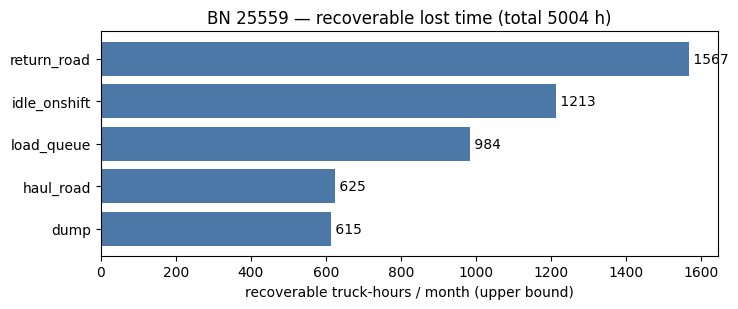

downtime (>6h/overnight, a STAFFING lever, not counted as recoverable): 4366 truck-h/mo


In [3]:
b = dx['attribution']['recoverable_truck_h']
items = sorted(b.items(), key=lambda x: x[1])
labels = [k for k, _ in items]; vals = [v for _, v in items]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(labels, vals, color='#4c78a8')
ax.set_xlabel('recoverable truck-hours / month (upper bound)')
ax.set_title(f"BN {dx['zone_id']} — recoverable lost time (total {dx['attribution']['total_truck_h']} h)")
for i, v in enumerate(vals): ax.text(v, i, f' {v}', va='center')
plt.tight_layout(); plt.show()
print(f"downtime (>6h/overnight, a STAFFING lever, not counted as recoverable): "
      f"{dx['attribution']['downtime_truck_h']} truck-h/mo")

## 3. Capacity and the realistic ceiling (Theory of Constraints)

Keeping the **actual fleet availability**, cutting the active-cycle waste (queue + road) lifts
throughput to `ceiling_active`; running more truck-hours (addressing downtime) can push up to the
shovel ceiling. This is more conservative — and credible — than assuming trucks run 24/7.

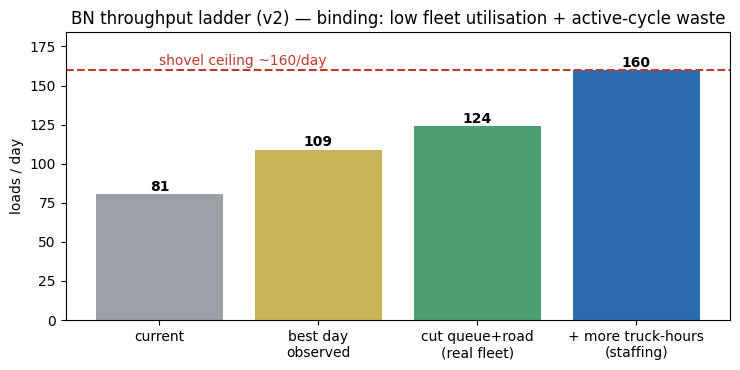

In [4]:
d = dx['decision']; t = dx['throughput']
steps = [('current', t['loads_day']),
         ('best day\nobserved', t['best_day']),
         ('cut queue+road\n(real fleet)', d['ceiling_active']),
         ('+ more truck-hours\n(staffing)', d['shovel_ceiling'])]
labels = [s[0] for s in steps]; vals = [s[1] for s in steps]
colors = ['#9aa0a6', '#c9b458', '#4c9f70', '#2b6cb0']
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(labels, vals, color=colors)
ax.axhline(d['shovel_ceiling'], ls='--', color='#c0392b')
ax.text(0, d['shovel_ceiling'] + 3, f"shovel ceiling ~{d['shovel_ceiling']}/day", color='#c0392b')
for i, v in enumerate(vals): ax.text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')
ax.set_ylim(0, d['shovel_ceiling'] * 1.15); ax.set_ylabel('loads / day')
ax.set_title("BN throughput ladder (v2) — binding: low fleet utilisation + active-cycle waste")
plt.tight_layout(); plt.show()

## 4. Same code, different diagnosis (Middling 25385)

The key check that the method generalises. BN has a long 34 km haul and road helps; Middling
has a short in-pit cycle where road ≈ 0 and the queue is the active lever. Same function.

In [5]:
import pandas as pd
dm = diagnose(25385)

def summ(z):
    dd, cc, tt = z['decision'], z['capacity'], z['throughput']
    top = max(z['attribution']['recoverable_truck_h'].items(), key=lambda x: x[1])[0]
    return {'loads/day': tt['loads_day'], 'trucks': tt['trucks'],
            'full cycle (min)': z['cycle']['full_cycle_min'],
            'shovel utilisation': f"{cc['utilisation']*100:.0f}%",
            'top recoverable bucket': top,
            'does fixing roads help?': dd['road_helps'],
            'active ceiling (loads/day)': dd['ceiling_active'],
            'shovel ceiling (loads/day)': dd['shovel_ceiling']}

pd.DataFrame({dx['name']: summ(dx), dm['name']: summ(dm)})

,BN load (Баруун наран /Зүүн/),Middling load
loads/day,80.6,159.9
trucks,22,21
full cycle (min),222.1,43.8
shovel utilisation,50%,34%
top recoverable bucket,return_road,idle_onshift
does fixing roads help?,True,True
active ceiling (loads/day),124,299
shovel ceiling (loads/day),160,477


## 5. Layer 4 — the manager brief (LLM)

The last layer sends the structured diagnosis (JSON) to Claude (`claude-opus-4-8`) and asks for a
short manager brief, grounded only in the numbers with the honest limits. Example from the v2 BN
diagnosis:

> **BN loading zone (25559) — November 2025 haulage brief**
>
> **Bottom line:** The loading shovel is *not* the bottleneck — it runs at about 50%. Two things
> cost loads: trucks queue at the shovel and lose time on the road, and the fleet is parked or
> off-shift a large share of the month.
>
> **What is realistic (no new equipment).** Smoothing arrivals to cut the queue and improving the
> haul road — while keeping today's fleet hours — could lift this zone from ~81 to ~124 loads/day
> (+54%). That is close to the best day already seen (109), so it is credible.
>
> **A separate, bigger lever.** The fleet stands idle/off-shift about 4,366 truck-hours a month.
> Running more productive truck-hours (extra shifts, more available trucks) could push output toward
> the shovel ceiling (~160 loads/day) — but that is a staffing and scheduling decision, not dispatch,
> and some of that standstill is legitimate (maintenance, rest).
>
> **Read this honestly.** A diagnosis, not a promise. Figures are upper bounds from November data
> only; no payload data (units are loads/truck-hours, not tonnes). To confirm a gain, run one lever
> as a pilot and re-run this same analysis on the after-data.

Generate a fresh brief live (needs an Anthropic API key):

```bash
export ANTHROPIC_API_KEY=sk-ant-...
python agent_explain.py 25559            # English
python agent_explain.py 25559 --lang zh  # Chinese
```

## Honest limits

- A **diagnostic**, not an optimiser. It does not control the trucks.
- Recoverable numbers are **upper bounds**, from November data only.
- The 6 h idle threshold is a **provisional, BN-tuned** value → make it cycle-relative when generalising.
- No payload data, so the unit is loads and truck-hours, not tonnes.
- Observational data cannot prove an improvement — a real gain needs a **before/after pilot**.